# 03. Khai phá và phân tích dữ liệu EDA

Notebook này tương ứng **Bước 3: Khai phá và phân tích dữ liệu**.

Mục tiêu là đặt câu hỏi và trả lời bằng biểu đồ.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

DEFAULT_ROOT = Path(r"C:\vscode\hoctap\Customer-Churn-Analysis")

def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents, DEFAULT_ROOT]:
        if (candidate / 'src').exists() and (candidate / 'configs').exists():
            return candidate
    raise FileNotFoundError('Khong tim thay project root.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import load_dataset
from src.data.preprocess import clean_dataframe
from src.utils.config import load_project_config

sns.set_theme(style='whitegrid')
config = load_project_config(PROJECT_ROOT / 'configs' / 'config.yaml')
df = clean_dataframe(load_dataset(PROJECT_ROOT / config['paths']['raw_data']))
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Tỷ lệ churn tổng thể

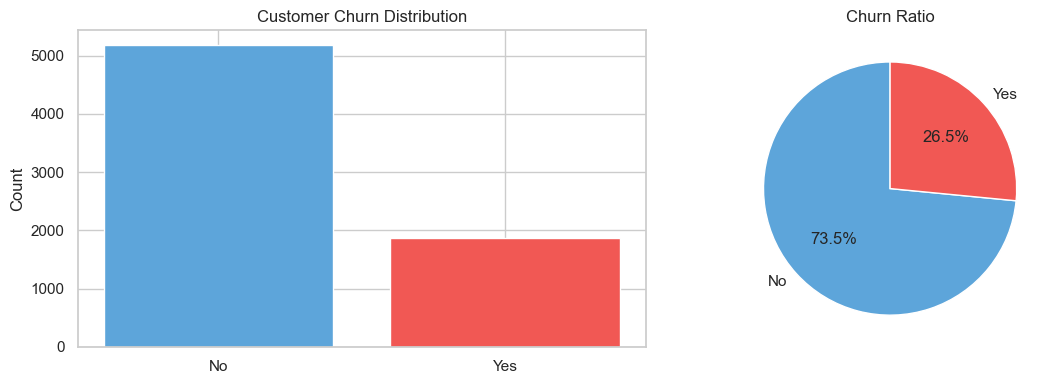

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [2]:
churn_counts = df['Churn'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(churn_counts.index, churn_counts.values, color=['#5DA5DA', '#F15854'])
axes[0].set_title('Customer Churn Distribution')
axes[0].set_ylabel('Count')
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#5DA5DA', '#F15854'], wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Churn Ratio')
plt.tight_layout()
plt.show()
df['Churn'].value_counts(normalize=True).mul(100).round(2)

## 2. Churn theo hợp đồng và thanh toán

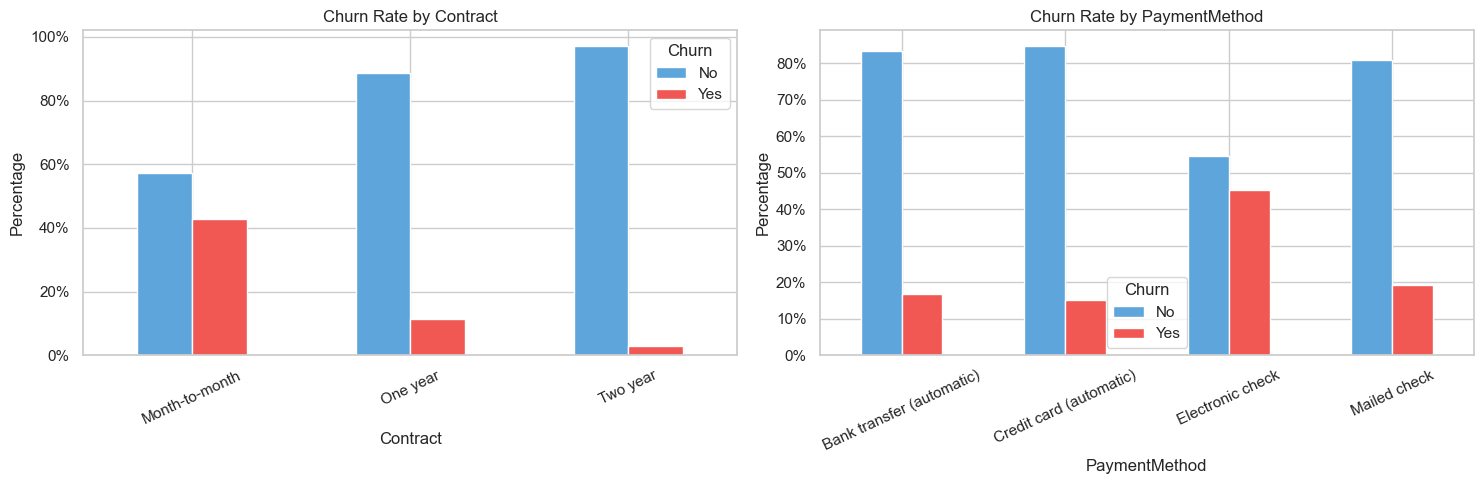

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col in zip(axes, ['Contract', 'PaymentMethod']):
    rate = pd.crosstab(df[col], df['Churn'], normalize='index').mul(100)
    rate.plot(kind='bar', ax=ax, color=['#5DA5DA', '#F15854'])
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Percentage')
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## 3. Churn theo dịch vụ hỗ trợ

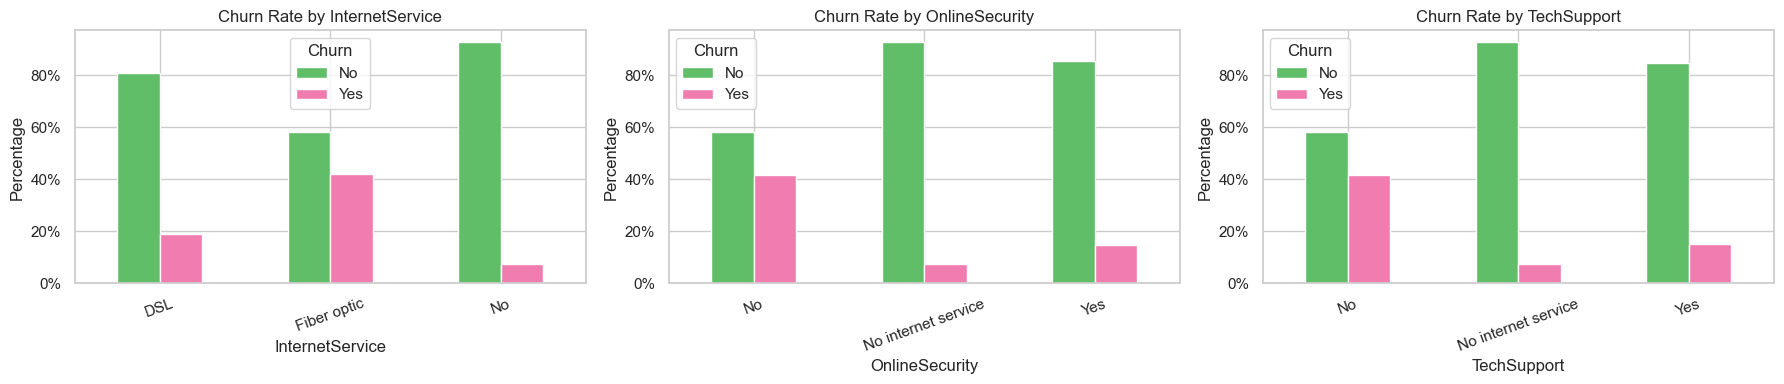

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ['InternetService', 'OnlineSecurity', 'TechSupport']):
    rate = pd.crosstab(df[col], df['Churn'], normalize='index').mul(100)
    rate.plot(kind='bar', ax=ax, color=['#60BD68', '#F17CB0'])
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Percentage')
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 4. Phân phối tenure, MonthlyCharges, TotalCharges

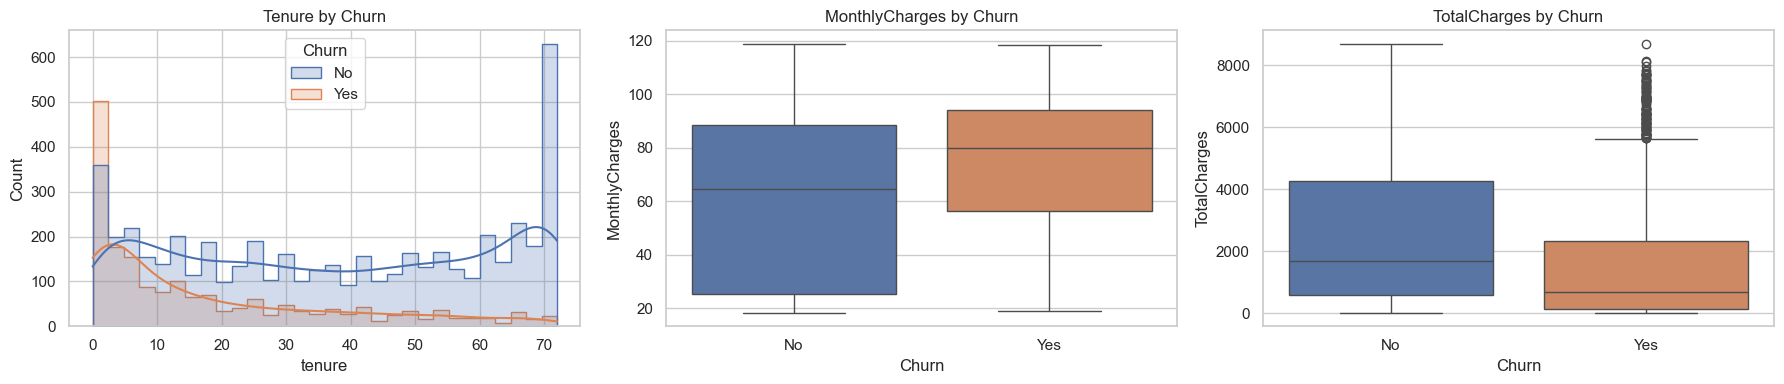

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, element='step', ax=axes[0])
axes[0].set_title('Tenure by Churn')
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', ax=axes[1])
axes[1].set_title('MonthlyCharges by Churn')
if axes[1].legend_ is not None:
    axes[1].legend_.remove()
sns.boxplot(data=df, x='Churn', y='TotalCharges', hue='Churn', ax=axes[2])
axes[2].set_title('TotalCharges by Churn')
if axes[2].legend_ is not None:
    axes[2].legend_.remove()
plt.tight_layout()
plt.show()

## Kết luận bước 3

- `Month-to-month` thường có churn cao.
- `tenure` thấp thường liên quan đến churn cao.
- `MonthlyCharges`, `TechSupport`, `OnlineSecurity`, `PaymentMethod` là các biến đáng chú ý.